# Figure 1 · Clinical problem and evaluation traps

> One figure, one notebook. 1A–1C read frozen artifacts from `00_data_preparation.ipynb` (`results/notebooks/00_data/`, Full set); 1D additionally reads/recomputes binary-baseline mean AUROC under four evaluation protocols as a bridge for “why honest evaluation is needed”.

**Four-panel layout**:

- **1A｜Training vs global prevalence mismatch** — dual pies: global B ~11% vs training B ~95%.
- **1B｜Within-patient sequence redundancy** — dumbbell plot, records collapsing to patients.
- **1C｜Class scale and subtype composition** — stacked bars by subtype with end-of-bar non-B %.
- **1D｜Evaluation-protocol ladder** — schematic + binary-baseline mean AUROC: Random CV → Patient CV → Cluster OOD → Subtype OOD.

**Takeaway**: reference data are heavily B-biased and have within-patient redundancy; resistance CDS tools must extrapolate beyond B, so evaluation must prevent leakage and test out-of-distribution generalization.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

DATA00 = PROJECT_ROOT / "results" / "notebooks" / "00_data"
PREP = PROJECT_ROOT / "work" / "prepared"
FIG_DIR = PROJECT_ROOT / "figures" / "manuscript" / "fig1"
OUT_DIR = PROJECT_ROOT / "results" / "notebooks" / "fig1"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = ["PI", "NRTI", "NNRTI", "INSTI"]
GENE_OF_CLASS = {"PI": "PR", "NRTI": "RT", "NNRTI": "RT", "INSTI": "IN", "CAI": "CA"}
PAPER_DRUGS = {
    "PI": ["FPV", "ATV", "IDV", "LPV", "NFV", "SQV", "TPV", "DRV"],
    "NRTI": ["3TC", "ABC", "AZT", "D4T", "DDI", "TDF"],
    "NNRTI": ["EFV", "ETR", "NVP", "RPV"],
    "INSTI": ["RAL", "EVG", "DTG", "BIC", "CAB"],
}

def collapse_subtype(s):
    if pd.isna(s) or s in ("Unknown", "U", ""):
        return "Unknown"
    return "B" if s == "B" else "non-B"

def ensure_fig1_00_data():
    required = [
        "global_subtype_baseline.csv",
        "train_vs_global_subtype.csv",
        "subtype_composition.csv",
        "sample_caliber.csv",
        "data_summary.csv",
    ]
    if all((DATA00 / name).exists() for name in required):
        return "existing"

    DATA00.mkdir(parents=True, exist_ok=True)
    cal_rows, drug_rows, comp_rows, detail_rows = [], [], [], []
    frames = {
        cls: pd.read_csv(PREP / f"{cls}.csv", dtype={"SeqID": str, "PtID": str})
        for cls in CLASS_ORDER
    }

    for cls, df in frames.items():
        dedup = df.drop_duplicates(subset=["SeqID"])
        seqs = dedup["sequence"].astype(str)
        cal_rows.append({
            "drug_class": cls,
            "records": len(df),
            "patients": int(dedup["PtID"].nunique()) if dedup["PtID"].notna().any() else None,
            "isolates": int(dedup["SeqID"].nunique()),
            "unique_sequences": int(seqs.nunique()),
            "records_per_unique_seq": round(len(df) / seqs.nunique(), 3),
        })
        for drug in PAPER_DRUGS[cls]:
            col = f"{drug}_label"
            if col not in df.columns:
                continue
            y = pd.to_numeric(df[col], errors="coerce")
            valid = y.notna()
            n_valid = int(valid.sum())
            n_resistant = int(y[valid].sum()) if n_valid else 0
            drug_rows.append({
                "drug_class": cls,
                "drug": drug,
                "gene": GENE_OF_CLASS[cls],
                "n_valid": n_valid,
                "n_resistant": n_resistant,
                "prevalence": n_resistant / n_valid if n_valid else np.nan,
            })
        st = dedup["Subtype"]
        grp = st.map(collapse_subtype).value_counts()
        b, nb, unk = int(grp.get("B", 0)), int(grp.get("non-B", 0)), int(grp.get("Unknown", 0))
        tot = b + nb + unk
        comp_rows.append({
            "drug_class": cls,
            "B": b,
            "non_B": nb,
            "Unknown": unk,
            "total": tot,
            "non_B_pct": round(100 * nb / tot, 1) if tot else 0,
        })
        for sub, n in st[st.map(collapse_subtype) == "non-B"].value_counts().items():
            detail_rows.append({"drug_class": cls, "subtype": sub, "n": int(n)})

    def add_all(dfx, sum_cols):
        row = {c: (dfx[c].sum() if c in sum_cols else "ALL") for c in dfx.columns}
        return pd.concat([dfx, pd.DataFrame([row])], ignore_index=True)

    caliber = add_all(pd.DataFrame(cal_rows), ["records", "patients", "isolates", "unique_sequences"])
    caliber.loc[caliber.index[-1], "records_per_unique_seq"] = round(
        caliber["records"][:-1].sum() / caliber["unique_sequences"][:-1].sum(), 3)
    comp = add_all(pd.DataFrame(comp_rows), ["B", "non_B", "Unknown", "total"])
    comp.loc[comp.index[-1], "non_B_pct"] = round(
        100 * comp["non_B"][:-1].sum() / comp["total"][:-1].sum(), 1)

    gb = pd.DataFrame([
        ("C", 50.4, 50.2, 50.7), ("A", 12.4, 12.2, 12.6),
        ("B", 11.3, 11.1, 11.5), ("G", 2.9, 2.9, 3.0),
        ("D", 2.6, 2.5, 2.7), ("F", 0.9, 0.8, 0.9),
        ("CRFs", 15.1, 14.9, 15.3), ("URFs", 2.0, 1.9, 2.1),
    ], columns=["subtype", "global_pct", "ci_low", "ci_high"])
    gb["source"] = "Hemelaar_LancetMicrobe_2024"
    gb["window"] = "2016-2021"

    all_comp = comp[comp["drug_class"] == "ALL"].iloc[0]
    train_B = 100 * all_comp["B"] / (all_comp["B"] + all_comp["non_B"])
    cmp2 = pd.DataFrame({
        "group": ["B", "non-B"],
        "hivdb_train_pct": [round(train_B, 1), round(100 - train_B, 1)],
        "global_2016_21_pct": [11.3, 88.7],
    })

    caliber.to_csv(DATA00 / "sample_caliber.csv", index=False)
    pd.DataFrame(drug_rows).to_csv(DATA00 / "data_summary.csv", index=False)
    comp.to_csv(DATA00 / "subtype_composition.csv", index=False)
    pd.DataFrame(detail_rows).to_csv(DATA00 / "subtype_detail.csv", index=False)
    gb.to_csv(DATA00 / "global_subtype_baseline.csv", index=False)
    cmp2.to_csv(DATA00 / "train_vs_global_subtype.csv", index=False)
    return "generated from work/prepared"

source_state = ensure_fig1_00_data()
print("data source :", DATA00.relative_to(PROJECT_ROOT), f"({source_state})")
print("products    :", sorted(p.name for p in DATA00.glob("*.csv")))

data source : results/notebooks/00_data (existing)
products    : ['data_summary.csv', 'global_subtype_baseline.csv', 'sample_caliber.csv', 'sequence_qc.csv', 'subtype_composition.csv', 'subtype_detail.csv', 'train_vs_global_subtype.csv']


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
# Four main-analysis classes (usable non-B; subtype OOD feasible)
CLASS_ORDER = ["PI", "NRTI", "NNRTI", "INSTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100", "INSTI": "#9467bd"}
# Subtype colors: B cool blue (abundant/familiar), non-B warm orange (globally common but scarce in data / hard to extrapolate), Unknown gray
SUBTYPE_COLOR = {"B": "#2a78d6", "non-B": "#eb6834", "Unknown": "#c9c8c4"}
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})
print("palette ready")


palette ready


## 1A · Training vs global prevalence mismatch (real data)

Core message of Figure 1A: **the training subtype mix is nearly inverted relative to global prevalence.** The world map is a schematic background from an external vector tool; this notebook produces the two comparison bars that carry the argument.

- **Left｜Global prevalence** (Lancet Microbe 2024, 2016–21): C 50.4%, A 12.4%, B 11.3%… non-B ≈ 89% total.
- **Right｜HIVDB training data** (this project's Full set): B ≈ 94.5%, non-B only 5.5%.
- Data sources: `00_data/global_subtype_baseline.csv` + `00_data/train_vs_global_subtype.csv` + `subtype_composition.csv`.
- Wording guardrail: the claim is “training is B-biased and models must extrapolate to non-B”, **not** “non-B cannot be predicted”.


In [3]:
# Load three tables needed by 1A
gb = pd.read_csv(DATA00 / "global_subtype_baseline.csv")          # global prevalence detail (2016-21)
tv = pd.read_csv(DATA00 / "train_vs_global_subtype.csv")          # training vs global (B/non-B)
comp = pd.read_csv(DATA00 / "subtype_composition.csv")            # HIVDB per-class composition
train_B = tv.loc[tv.group == "B", "hivdb_train_pct"].iloc[0]
global_B = tv.loc[tv.group == "B", "global_2016_21_pct"].iloc[0]
print(f"Global B={global_B}% vs HIVDB training B={train_B}%  → mismatch {train_B-global_B:.0f} percentage points")
gb

Global B=11.3% vs HIVDB training B=94.5%  → mismatch 83 percentage points


,subtype,global_pct,ci_low,ci_high,source,window
0,C,50.4,50.2,50.7,Hemelaar_LancetMicrobe_2024,2016-2021
1,A,12.4,12.2,12.6,Hemelaar_LancetMicrobe_2024,2016-2021
2,B,11.3,11.1,11.5,Hemelaar_LancetMicrobe_2024,2016-2021
3,G,2.9,2.9,3.0,Hemelaar_LancetMicrobe_2024,2016-2021
4,D,2.6,2.5,2.7,Hemelaar_LancetMicrobe_2024,2016-2021
5,F,0.9,0.8,0.9,Hemelaar_LancetMicrobe_2024,2016-2021
6,CRFs,15.1,14.9,15.3,Hemelaar_LancetMicrobe_2024,2016-2021
7,URFs,2.0,1.9,2.1,Hemelaar_LancetMicrobe_2024,2016-2021


saved fig1A_train_vs_global.png (two pies)


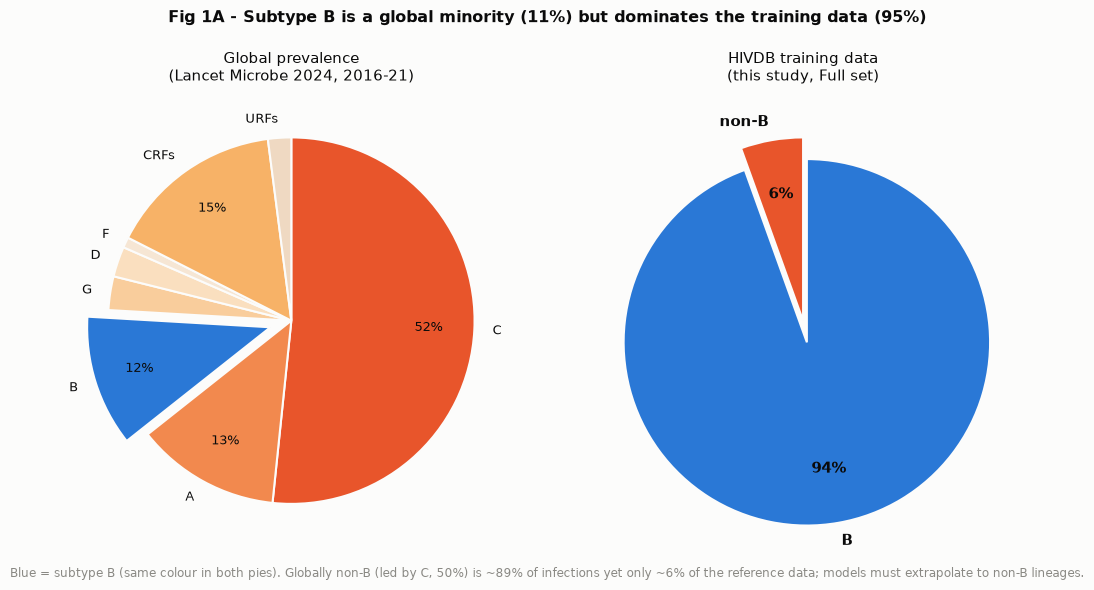

In [4]:
# 1A main: two side-by-side pies (left=global detail, right=HIVDB training)
# Color key: same cool blue for B on both pies; warm palette for all non-B (C brightest orange) → left pie is mostly warm with a blue wedge, right pie is mostly blue
B_BLUE = "#2a78d6"
WARM = {"C": "#e8552b", "A": "#f2894e", "CRFs": "#f7b267", "G": "#f9cd9c",
        "D": "#fadfbf", "F": "#f6e6d4", "URFs": "#efd9c2", "non-B": "#e8552b"}

train_nonB = tv.loc[tv.group == "non-B", "hivdb_train_pct"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.4))

# Left pie: global detail (B blue, others warm; explode B for emphasis)
gl_labels = gb["subtype"].tolist()
gl_vals = gb["global_pct"].tolist()
gl_colors = [B_BLUE if s == "B" else WARM.get(s, "#e0dfdb") for s in gl_labels]
gl_explode = [0.12 if s == "B" else 0 for s in gl_labels]
axes[0].pie(gl_vals, labels=gl_labels, colors=gl_colors, explode=gl_explode,
            autopct=lambda p: f"{p:.0f}%" if p >= 5 else "", pctdistance=0.75,
            startangle=90, counterclock=False,
            wedgeprops=dict(edgecolor=SURFACE, linewidth=1.5),
            textprops=dict(fontsize=9, color=INK))
axes[0].set_title("Global prevalence\n(Lancet Microbe 2024, 2016-21)",
                  fontsize=10.5, color=INK, pad=8)

# Right pie: HIVDB training B vs non-B (same blue for B, explode for emphasis)
axes[1].pie([train_B, train_nonB], labels=["B", "non-B"],
            colors=[B_BLUE, WARM["non-B"]], explode=[0.12, 0],
            autopct=lambda p: f"{p:.0f}%", pctdistance=0.7,
            startangle=90, counterclock=False,
            wedgeprops=dict(edgecolor=SURFACE, linewidth=1.5),
            textprops=dict(fontsize=11, color=INK, fontweight="bold"))
axes[1].set_title("HIVDB training data\n(this study, Full set)",
                  fontsize=10.5, color=INK, pad=8)

fig.suptitle("Fig 1A - Subtype B is a global minority (11%) but dominates the training data (95%)",
             x=0.5, y=1.03, fontsize=11.5, color=INK, fontweight="bold")
fig.text(0.5, -0.02,
         "Blue = subtype B (same colour in both pies). Globally non-B (led by C, 50%) is ~89% of "
         "infections yet only ~6% of the reference data; models must extrapolate to non-B lineages.",
         ha="center", color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1A_train_vs_global.png", dpi=150, bbox_inches="tight")
tv.to_csv(OUT_DIR / "train_vs_global_subtype.csv", index=False)
gb.to_csv(OUT_DIR / "global_subtype_baseline.csv", index=False)
print("saved fig1A_train_vs_global.png (two pies)")
plt.show()

In [5]:
# 1A numeric check (print values for caption/review)
train_nonB = tv.loc[tv.group == "non-B", "hivdb_train_pct"].iloc[0]
global_nonB = tv.loc[tv.group == "non-B", "global_2016_21_pct"].iloc[0]
print("Fig 1A two pies — B / non-B shares on each side:")
print(tv.to_string(index=False))
print("\nGlobal prevalence detail (left pie, Lancet Microbe 2024):")
print(gb[["subtype", "global_pct"]].to_string(index=False))
print(f"\nB:     global {global_B:.0f}% → training {train_B:.0f}%")
print(f"non-B: global {global_nonB:.0f}% → training {train_nonB:.0f}% (global non-B dominated by C ~50%)")

Fig 1A two pies — B / non-B shares on each side:
group  hivdb_train_pct  global_2016_21_pct
    B             94.5                11.3
non-B              5.5                88.7

Global prevalence detail (left pie, Lancet Microbe 2024):
subtype  global_pct
      C        50.4
      A        12.4
      B        11.3
      G         2.9
      D         2.6
      F         0.9
   CRFs        15.1
   URFs         2.0

B:     global 11% → training 94%
non-B: global 89% → training 6% (global non-B dominated by C ~50%)


## 1B · Data redundancy: records collapse to patients (real data)

Core message of Figure 1B: **the same patient contributes multiple highly similar sequences**—the physical source of leakage under random splits (same-patient sequences land on both train and test).

Use a **collapse dumbbell**: one row per drug class; left=raw records, right=unique patients; segment length = collapsed duplicate records. Annotate records/patient on the right—larger means more within-patient repeats.

- Data: `00_data/sample_caliber.csv` (records / patients, Full set).
- Takeaway: records ≫ patients (e.g., NRTI 2652→1391, INSTI 2016→724); random CV easily splits same-patient sequences across folds and leaks signal—so evaluation must be patient-grouped.

saved fig1B_records_to_patients.png


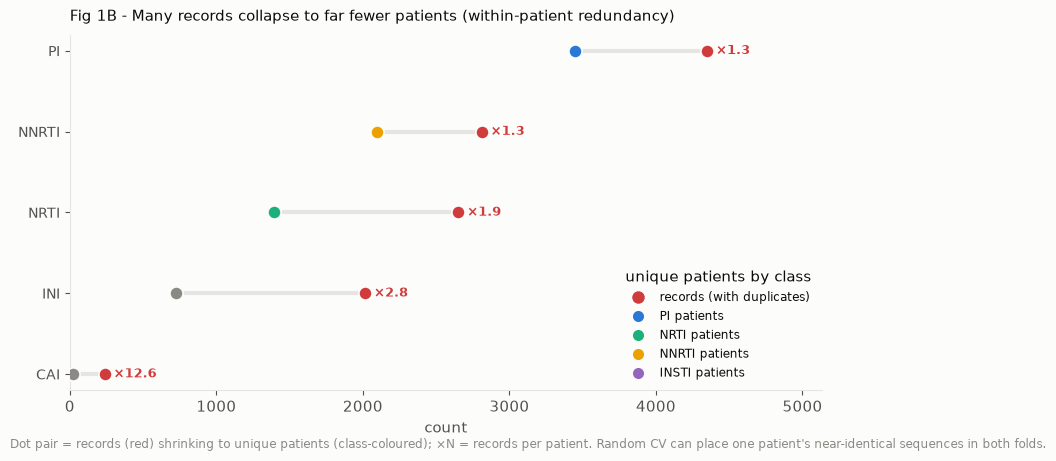

In [6]:
# 1B main: collapse dumbbell (records → patients), one row per class
caliber = pd.read_csv(DATA00 / "sample_caliber.csv")
cal = caliber[caliber["drug_class"] != "ALL"].copy()
cal["rec_per_pt"] = (cal["records"] / cal["patients"]).round(2)
cal = cal.sort_values("rec_per_pt", ascending=True).reset_index(drop=True)
cal.to_csv(OUT_DIR / "sample_caliber.csv", index=False)

fig, ax = plt.subplots(figsize=(8.4, 0.6 * len(cal) + 1.6))
ypos = np.arange(len(cal))[::-1]
for i, r in cal.iterrows():
    col = CLASS_COLOR.get(r["drug_class"], INK3)
    ax.plot([r["patients"], r["records"]], [ypos[i], ypos[i]], "-",
            color=GRID, lw=3, zorder=1)
    ax.scatter(r["records"], ypos[i], s=90, color=CRIT, zorder=3,
               edgecolor=SURFACE, linewidth=1.2)   # records (with duplicates)
    ax.scatter(r["patients"], ypos[i], s=90, color=col, zorder=3,
               edgecolor=SURFACE, linewidth=1.2)    # patients (colored by class)
    ax.text(r["records"] + 60, ypos[i], f"×{r['rec_per_pt']:.1f}",
            va="center", ha="left", fontsize=9, color=CRIT, fontweight="bold")

ax.set_yticks(ypos)
ax.set_yticklabels([f"{c}" for c in cal["drug_class"]], fontsize=10)
ax.set_xlabel("count")
ax.set_xlim(0, cal["records"].max() * 1.18)
ax.set_title("Fig 1B - Many records collapse to far fewer patients (within-patient redundancy)",
             loc="left", color=INK, fontsize=11, pad=10)
# Legend: records in red; unique patients use blue/green/orange/purple by class
from matplotlib.lines import Line2D
record_handle = Line2D([0], [0], marker="o", color="none", markerfacecolor=CRIT,
                       markeredgecolor=SURFACE, markersize=10, label="records (with duplicates)")
patient_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CLASS_COLOR[c],
           markeredgecolor=SURFACE, markersize=9, label=f"{c} patients")
    for c in CLASS_ORDER
]
ax.legend(handles=[record_handle] + patient_handles, loc="lower right", frameon=False,
          fontsize=8.5, ncol=1, title="unique patients by class")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.text(0.01, 0.01,
         "Dot pair = records (red) shrinking to unique patients (class-coloured); ×N = records per "
         "patient. Random CV can place one patient's near-identical sequences in both folds.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1B_records_to_patients.png", dpi=150, bbox_inches="tight")
print("saved fig1B_records_to_patients.png")
plt.show()

## 1C · Dataset scale and subtype composition (real data)

Show **class-level scale and subtype mix** (together with 1A mismatch and 1B redundancy: three views of the dataset). No per-drug scarcity callouts here (see Figure 4A) to avoid duplication.

- One row per drug class showing B / non-B / Unknown isolate composition.
- Annotate B isolate counts inside B segments; end each bar with `non-B x%` to stress non-B reference scarcity per class.
- Data: `00_data/subtype_composition.csv`.


In [7]:
# Load 1C table: class × subtype composition
comp = pd.read_csv(DATA00 / "subtype_composition.csv")
comp_main = comp[comp["drug_class"].isin(CLASS_ORDER)].set_index("drug_class").reindex(CLASS_ORDER)
print("Class × subtype composition:")
print(comp_main[["B", "non_B", "Unknown", "total", "non_B_pct"]].to_string())

Class × subtype composition:
                 B  non_B  Unknown   total  non_B_pct
drug_class                                           
PI          4040.0  242.0     10.0  4292.0        5.6
NRTI        1542.0   55.0      3.0  1600.0        3.4
NNRTI       2572.0  147.0     13.0  2732.0        5.4
INSTI          NaN    NaN      NaN     NaN        NaN


ValueError: cannot convert float NaN to integer

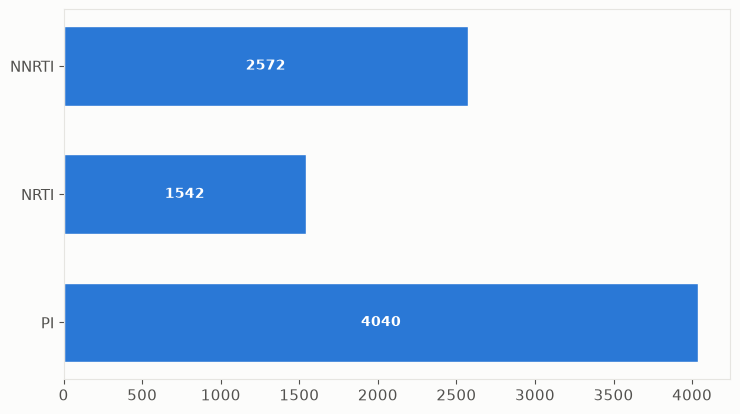

In [8]:
# 1C main: class sample size stacked by subtype; end-of-bar non-B %
fig, ax = plt.subplots(figsize=(8.6, 4.8))

left = np.zeros(len(CLASS_ORDER))
COLKEY = {"B": "B", "non-B": "non_B", "Unknown": "Unknown"}
for st in ["B", "non-B", "Unknown"]:
    vals = comp_main[COLKEY[st]].values
    ax.barh(CLASS_ORDER, vals, left=left, color=SUBTYPE_COLOR[st],
            edgecolor=SURFACE, label=st, height=0.62)
    if st == "B":
        for i, (v, l) in enumerate(zip(vals, left)):
            ax.text(l + v / 2, i, f"{int(v)}", ha="center", va="center",
                    color="white", fontsize=10, fontweight="bold")
    left += vals

for i, cls in enumerate(CLASS_ORDER):
    r = comp_main.loc[cls]
    ax.text(r["total"] + comp_main["total"].max() * 0.025, i,
            f"non-B {r['non_B_pct']:.1f}%", ha="left", va="center",
            fontsize=10, color=SUBTYPE_COLOR["non-B"], fontweight="bold")

ax.invert_yaxis()
ax.set_xlabel("number of isolates")
ax.set_xlim(0, comp_main["total"].max() * 1.20)
ax.set_title("Fig 1C - Dataset scale and subtype composition by drug class",
             loc="left", color=INK, fontsize=11.5, pad=10, fontweight="bold")
ax.legend(loc="lower right", frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.text(0.01, 0.01,
         "Bars show isolate counts in the Full set. Orange labels report the non-B fraction in each "
         "drug class, highlighting that non-B sequences remain scarce across all main analysis classes.",
         color=INK3, fontsize=8.5)
comp_main.to_csv(OUT_DIR / "class_subtype_scale.csv")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1C_scale_subtype.png", dpi=150, bbox_inches="tight")
print("saved fig1C_scale_subtype.png")
plt.show()

## 1D · Evaluation-protocol ladder (schematic + binary baseline mean AUROC)

Figure 1D upgrades from a pure schematic to a bridge plot (schematic + one real result row). It answers one question only: **how the same binary baseline's apparent AUROC changes/contracts under stricter, more deployment-like protocols**. It does not compare ESM vs binary, plot per-drug deltas, or show leakage similarity; method comparison is Fig3, leakage mechanics are Fig2.

Left to right, the four protocols move away from loose random splits and introduce different extrapolation pressures:

- **Random CV**: ordinary random StratifiedKFold; easily mixes same-patient or near-duplicate sequences; loose baseline.
- **Patient CV**: group by patient to stop same-patient train/test leakage.
- **Cluster OOD**: Cluster OOD uses fixed **k=12** (contract in `_common.CLUSTER_K`); leave-one-cluster-out tests sequence-space extrapolation.
- **Subtype OOD**: train on B, test on non-B for lineage extrapolation; deployment pressure that maps directly to Fig1A global subtype mismatch.

Data: Random/Patient/Cluster/Subtype all read the same binary baseline columns `random_binary`, `rg_binary`, `clu_binary`, `ood_binary` from the final deterministic four-protocol table `work/results/probe_protocol_full_selected_k.csv`.


In [ ]:
# 1D main panel: evaluation-protocol ladder (binary baseline; read final deterministic four-protocol table)
# Note: this panel only shows protocol effects, not method ranking; ESM vs binary is left to Fig3.

REF_DIR = PROJECT_ROOT / "notebooks" / "data" /  "refs"
RES = PROJECT_ROOT / "work" / "results"
PREP = PROJECT_ROOT / "work" / "prepared"
# Cluster OOD k is a fixed contract (see notebooks/scripts/_common.py CLUSTER_K).
K_STAR = 12
PROTOCOL_PATH = RES / "probe_protocol_full_selected_k.csv"
if not PROTOCOL_PATH.exists():
    raise FileNotFoundError(f"Missing {PROTOCOL_PATH}. Run probe_protocol_full_selected_k.py first.")
OOD_PATH = PROTOCOL_PATH

POL = "".join(l.strip() for l in (REF_DIR / "P04585.fasta").read_text().splitlines()
              if l and not l.startswith(">"))

def build_ref(src, s, e, patch):
    seq = list(src[s-1:e])
    for p, aa in patch.items():
        seq[p-1] = aa
    return "".join(seq)

REFS = {
    "PR": build_ref(POL, 489, 587, {3: "I"}),
    "RT": build_ref(POL, 588, 1187, {214: "F", 570: "E"}),
    "IN": build_ref(POL, 1148, 1435, {10: "E", 72: "I", 123: "S", 124: "T", 127: "K", 232: "D"}),
}
GENE_OF = {"PI": "PR", "NRTI": "RT", "NNRTI": "RT", "INSTI": "IN"}
DRUGS = {
    "PI": ["FPV", "ATV", "IDV", "LPV", "NFV", "SQV", "TPV", "DRV"],
    "NRTI": ["3TC", "ABC", "AZT", "D4T", "DDI", "TDF"],
    "NNRTI": ["EFV", "ETR", "NVP", "RPV"],
    "INSTI": ["RAL", "EVG", "DTG", "BIC", "CAB"],
}

probe = pd.read_csv(OOD_PATH)
random_df = probe[["class", "drug", "random_binary"]].copy()

protocol = pd.DataFrame([
    {"protocol": "Random CV", "auroc": probe["random_binary"].mean(),
     "role": "leaky", "mechanism": "records mixed"},
    {"protocol": "Patient CV", "auroc": probe["rg_binary"].mean(),
     "role": "leakage-aware", "mechanism": "patients held out"},
    {"protocol": "Cluster OOD", "auroc": probe["clu_binary"].mean(),
     "role": "sequence-space shift", "mechanism": f"k={K_STAR} clusters"},
    {"protocol": "Subtype OOD", "auroc": probe["ood_binary"].mean(),
     "role": "lineage shift", "mechanism": "B → non-B"},
])
protocol.to_csv(OUT_DIR / "protocol_ladder_binary_auc.csv", index=False)
print("selected k =", K_STAR, "| OOD source:", OOD_PATH.name)
print(protocol.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
x = np.arange(len(protocol))
y = protocol["auroc"].values
cols = ["#d03b3b", "#2a78d6", "#9467bd", "#1baf7a"]
ax.plot(x, y, "-", color=INK2, lw=1.8, zorder=1)
ax.scatter(x, y, s=220, color=cols, edgecolor=SURFACE, linewidth=2, zorder=3)
for i, r in protocol.iterrows():
    ax.text(i, r["auroc"] + 0.010, f"{r['auroc']:.3f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=cols[i])
    ax.text(i, r["auroc"] - 0.035, r["role"], ha="center", va="top", fontsize=8.5, color=INK2)
    ax.text(i, r["auroc"] - 0.055, r["mechanism"], ha="center", va="top", fontsize=8, color=INK3)
ax.set_xticks(x)
ax.set_xticklabels(protocol["protocol"], fontsize=9)
ax.set_ylabel("mean AUROC across drugs\n(binary mutation baseline)")
lo = max(0.5, np.nanmin(y) - 0.08)
hi = min(1.0, np.nanmax(y) + 0.06)
ax.set_ylim(lo, hi)
ax.annotate("more deployment-like / stringent", xy=(3, lo + 0.01), xytext=(0, lo + 0.01),
            arrowprops=dict(arrowstyle="->", color=INK3, lw=1.2),
            ha="center", va="bottom", color=INK3, fontsize=8.5)
ax.set_title("Fig 1D - Apparent AUROC contracts as evaluation becomes more deployment-like",
             loc="left", color=INK, fontsize=11.5, pad=10)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.text(0.01, -0.02,
         "Single binary baseline only: the panel motivates evaluation design, not model ranking. "
         f"Cluster OOD uses fixed k={K_STAR}; protocols use {OOD_PATH.name}.",
         color=INK3, fontsize=8.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1D_protocol_ladder.png", dpi=150, bbox_inches="tight")
print("saved fig1D_protocol_ladder.png")
plt.show()

### Combined-figure artifact inventory

| Panel | Type | Artifacts from this notebook |
|---|---|---|
| 1A | data figure | `train_vs_global_subtype.csv`, `global_subtype_baseline.csv`, `fig1A_train_vs_global.png` |
| 1B | Data figure | `sample_caliber.csv`, `fig1B_records_to_patients.png` |
| 1C | Data figure | `class_subtype_scale.csv`, `fig1C_scale_subtype.png` |
| 1D | Hybrid bridge figure | `protocol_ladder_binary_auc.csv`, `fig1D_protocol_ladder.png` |

The final Figure 1 combined figure is assembled in layout software. 1A–1C use `00_data` Full-set summary tables; 1D uses the binary-baseline protocol ladder only to illustrate evaluation-protocol effects, not to rank methods. Per-drug scarcity analysis is in Figure 4A (to avoid duplicating 1C).


## Combined Figure 1 · panels A–D

**Redraw** A–D from raw summary tables and the Fig1D result table instead of reading single-panel PNGs. This keeps fonts, sizes, line widths, titles, and legends consistent inside the combined figure; single-panel PNGs are only quick-check artifacts.

In [ ]:
# Combined Figure 1: redraw A-D from data, with one unified visual system
from matplotlib.lines import Line2D

# ---------- Text style controls ----------
TEXT_COLOR = "#000000"
PANEL_TITLE_SIZE = 14
AXIS_LABEL_SIZE = 14      # axis title font size: change this parameter
TICK_LABEL_SIZE = 12      # tick label font size: change this parameter
LEGEND_TEXT_SIZE = 10
ANNOTATION_SIZE = 10
PIE_LABEL_SIZE = 10
PATIENT_COLOR = "#2a78d6"

# ---------- Load data ----------
gb = pd.read_csv(DATA00 / "global_subtype_baseline.csv")
tv = pd.read_csv(DATA00 / "train_vs_global_subtype.csv")
caliber = pd.read_csv(DATA00 / "sample_caliber.csv")
comp = pd.read_csv(DATA00 / "subtype_composition.csv")
protocol_path = OUT_DIR / "protocol_ladder_binary_auc.csv"
if not protocol_path.exists():
    raise FileNotFoundError("Run Fig1D cell first to generate protocol_ladder_binary_auc.csv")
protocol = pd.read_csv(protocol_path)

train_B = tv.loc[tv.group == "B", "hivdb_train_pct"].iloc[0]
train_nonB = tv.loc[tv.group == "non-B", "hivdb_train_pct"].iloc[0]

cal = caliber[caliber["drug_class"] != "ALL"].copy()
cal["rec_per_pt"] = (cal["records"] / cal["patients"]).round(2)
cal = cal.sort_values("rec_per_pt", ascending=True).reset_index(drop=True)

# Fig1C: sort drug classes by total isolates, descending (NRTI last in current data)
comp_main = (
    comp[comp["drug_class"].isin(CLASS_ORDER)]
    .set_index("drug_class")
    .sort_values("total", ascending=False)
)
comp_order = comp_main.index.tolist()

# Enforce current Fig1D order even if an older csv exists, and simplify first role label.
protocol_order = ["Random CV", "Patient CV", "Cluster OOD", "Subtype OOD"]
protocol = protocol.set_index("protocol").loc[protocol_order].reset_index()
protocol.loc[protocol["protocol"] == "Random CV", "role"] = "leaky"

# ---------- Unified figure style ----------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": PANEL_TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "legend.fontsize": LEGEND_TEXT_SIZE,
    "text.color": TEXT_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
})
fig = plt.figure(figsize=(16, 11.2), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, width_ratios=[1.08, 1.0], height_ratios=[1.0, 0.92],
                      wspace=0.24, hspace=0.34)

# ---------- A: training vs global subtype mismatch ----------
ax = fig.add_subplot(gs[0, 0])
B_BLUE = SUBTYPE_COLOR["B"]
WARM = {"C": "#e8552b", "A": "#f2894e", "CRFs": "#f7b267", "G": "#f9cd9c",
        "D": "#fadfbf", "F": "#f6e6d4", "URFs": "#efd9c2", "non-B": "#e8552b"}

left_pie = ax.inset_axes([0.00, 0.08, 0.48, 0.78])
right_pie = ax.inset_axes([0.52, 0.08, 0.48, 0.78])
for pie_ax in (left_pie, right_pie):
    pie_ax.set_aspect("equal")
    pie_ax.set_axis_off()

gl_labels = gb["subtype"].tolist()
gl_vals = gb["global_pct"].tolist()
gl_colors = [B_BLUE if s == "B" else WARM.get(s, "#e0dfdb") for s in gl_labels]
gl_explode = [0.10 if s == "B" else 0 for s in gl_labels]
left_pie.pie(gl_vals, labels=gl_labels, colors=gl_colors, explode=gl_explode,
             autopct=lambda p: f"{p:.0f}%" if p >= 5 else "", pctdistance=0.72,
             startangle=90, counterclock=False,
             wedgeprops=dict(edgecolor=SURFACE, linewidth=1.2),
             textprops=dict(fontsize=PIE_LABEL_SIZE, color=TEXT_COLOR))
left_pie.set_title("Global prevalence\n2016–2021", fontsize=12, pad=4, color=TEXT_COLOR)
right_pie.pie([train_B, train_nonB], labels=["B", "non-B"],
              colors=[B_BLUE, WARM["non-B"]], explode=[0.10, 0],
              autopct=lambda p: f"{p:.0f}%", pctdistance=0.68,
              startangle=90, counterclock=False,
              wedgeprops=dict(edgecolor=SURFACE, linewidth=1.2),
              textprops=dict(fontsize=PIE_LABEL_SIZE, color=TEXT_COLOR, fontweight="bold"))
right_pie.set_title("HIVDB reference data\nFull set", fontsize=12, pad=4, color=TEXT_COLOR)
ax.set_axis_off()
ax.set_title("A  Global vs reference subtype distribution",
             loc="left", fontsize=PANEL_TITLE_SIZE, fontweight="bold", color=TEXT_COLOR, pad=6)

# ---------- B: records collapse to patients ----------
ax = fig.add_subplot(gs[0, 1])
ypos = np.arange(len(cal))[::-1]
for i, r in cal.iterrows():
    ax.plot([r["patients"], r["records"]], [ypos[i], ypos[i]], "-", color=GRID, lw=3, zorder=1)
    ax.scatter(r["records"], ypos[i], s=78, color=CRIT, edgecolor=SURFACE, linewidth=1.1, zorder=3)
    ax.scatter(r["patients"], ypos[i], s=78, color=PATIENT_COLOR, edgecolor=SURFACE, linewidth=1.1, zorder=3)
    ax.text(r["records"] + 55, ypos[i], f"×{r['rec_per_pt']:.1f}",
            va="center", ha="left", fontsize=ANNOTATION_SIZE, color=TEXT_COLOR, fontweight="bold")
ax.set_yticks(ypos)
ax.set_yticklabels(cal["drug_class"], color=TEXT_COLOR)
ax.set_xlabel("count", fontsize=AXIS_LABEL_SIZE, color=TEXT_COLOR)
ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE, colors=TEXT_COLOR)
ax.set_xlim(0, cal["records"].max() * 1.20)
ax.set_title("B  Within-patient redundancy",
             loc="left", fontsize=PANEL_TITLE_SIZE, fontweight="bold", color=TEXT_COLOR, pad=6)
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CRIT,
           markeredgecolor=SURFACE, markersize=8.5, label="records"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=PATIENT_COLOR,
           markeredgecolor=SURFACE, markersize=8.5, label="patients"),
]
leg = ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=LEGEND_TEXT_SIZE)
for txt in leg.get_texts():
    txt.set_color(TEXT_COLOR)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# ---------- C: class subtype composition ----------
ax = fig.add_subplot(gs[1, 0])
left = np.zeros(len(comp_order))
COLKEY = {"B": "B", "non-B": "non_B", "Unknown": "Unknown"}
for st in ["B", "non-B", "Unknown"]:
    vals = comp_main[COLKEY[st]].values
    ax.barh(comp_order, vals, left=left, color=SUBTYPE_COLOR[st], edgecolor=SURFACE,
            label=st, height=0.60)
    if st == "B":
        for i, (v, l) in enumerate(zip(vals, left)):
            ax.text(l + v / 2, i, f"{int(v)}", ha="center", va="center",
                    color=TEXT_COLOR, fontsize=ANNOTATION_SIZE, fontweight="bold")
    left += vals
for i, cls in enumerate(comp_order):
    r = comp_main.loc[cls]
    ax.text(r["total"] + comp_main["total"].max() * 0.025, i,
            f"non-B {r['non_B_pct']:.1f}%", ha="left", va="center",
            fontsize=ANNOTATION_SIZE - 1, color=TEXT_COLOR, fontweight="normal")
ax.invert_yaxis()
ax.set_xlabel("number of isolates", fontsize=AXIS_LABEL_SIZE, color=TEXT_COLOR)
ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE, colors=TEXT_COLOR)
ax.set_xlim(0, comp_main["total"].max() * 1.22)
ax.set_title("C  Subtype composition by drug class",
             loc="left", fontsize=PANEL_TITLE_SIZE, fontweight="bold", color=TEXT_COLOR, pad=6)
leg = ax.legend(loc="lower right", frameon=False, fontsize=LEGEND_TEXT_SIZE)
for txt in leg.get_texts():
    txt.set_color(TEXT_COLOR)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# ---------- D: evaluation protocol ladder ----------
ax = fig.add_subplot(gs[1, 1])
x = np.arange(len(protocol))
y = protocol["auroc"].values
cols = [CRIT, CLASS_COLOR["PI"], CLASS_COLOR["INSTI"], "#1baf7a"]
ax.plot(x, y, "-", color=INK2, lw=1.8, zorder=1)
ax.scatter(x, y, s=150, color=cols, edgecolor=SURFACE, linewidth=1.6, zorder=3)
for i, r in protocol.iterrows():
    ax.text(i, r["auroc"] + 0.010, f"{r['auroc']:.3f}", ha="center", va="bottom",
            fontsize=ANNOTATION_SIZE + 0.5, fontweight="bold", color=TEXT_COLOR)
    # Keep only one concise protocol-mechanism label inside the panel.
    x_text = i + (0.01 if i == 0 else 0.0)
    ha_text = "left" if i == 0 else "center"
    ax.text(x_text, r["auroc"] - 0.043, r["mechanism"], ha=ha_text, va="top",
            fontsize=ANNOTATION_SIZE - 0.5, color=TEXT_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(protocol["protocol"], fontsize=TICK_LABEL_SIZE, color=TEXT_COLOR)
ax.set_ylabel("Mean AUROC", fontsize=AXIS_LABEL_SIZE, color=TEXT_COLOR)
ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE, colors=TEXT_COLOR)
lo = max(0.5, np.nanmin(y) - 0.08)
hi = min(1.0, np.nanmax(y) + 0.06)
ax.set_ylim(lo, hi)
ax.set_title("D  AUROC across evaluation protocols",
             loc="left", fontsize=PANEL_TITLE_SIZE, fontweight="bold", color=TEXT_COLOR, pad=6)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# No global title: keep the assembled panel clean for manuscript layout.
fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig(FIG_DIR / "fig1_combined.png", dpi=180, bbox_inches="tight", facecolor=SURFACE)
fig.savefig(FIG_DIR / "fig1_combined.pdf", bbox_inches="tight", facecolor=SURFACE)
print("saved", FIG_DIR / "fig1_combined.png")
print("saved", FIG_DIR / "fig1_combined.pdf")
print("Axis label size controlled by AXIS_LABEL_SIZE; tick label size controlled by TICK_LABEL_SIZE.")
plt.show()